In [1]:
import os

# Clone the repo into Colab's session storage
if not os.path.exists('/content/civil-comments-moral-foundations'):
    !git clone https://github.com/iamahmadyasin/civil-comments-moral-foundations.git /content/civil-comments-moral-foundations

# Move into the project directory
os.chdir('/content/civil-comments-moral-foundations')
print("Working directory:", os.getcwd())
print("Files:", os.listdir('.'))

Cloning into '/content/civil-comments-moral-foundations'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 18 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 69.54 KiB | 354.00 KiB/s, done.
Resolving deltas: 100% (1/1), done.
Working directory: /content/civil-comments-moral-foundations
Files: ['src', 'notebooks', 'requirements.txt', '.git', '.gitignore', 'README.md', 'outputs', 'data']


In [2]:
!pip install -q datasets transformers torch pymc arviz pandas scikit-learn matplotlib seaborn
print("All packages installed.")

All packages installed.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Create output folders on Drive
DRIVE_BASE    = '/content/drive/MyDrive/Civil Comments Project'
FIGURES_DIR   = os.path.join(DRIVE_BASE, 'outputs/figures')
DATA_DIR      = os.path.join(DRIVE_BASE, 'data')
MF_SCORES_FILE = os.path.join(DATA_DIR, 'civil_comments_with_mf_scores.csv')

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(DATA_DIR,    exist_ok=True)

print("Drive mounted. Output folders ready.")
print(f"CSVs will save to:    {DATA_DIR}")
print(f"Figures will save to: {FIGURES_DIR}")

Mounted at /content/drive
Drive mounted. Output folders ready.
CSVs will save to:    /content/drive/MyDrive/Civil Comments Project/data
Figures will save to: /content/drive/MyDrive/Civil Comments Project/outputs/figures


In [4]:
import getpass

# Token entered securely
HF_TOKEN     = getpass.getpass("Paste your Hugging Face token and press Enter: ")
DATASET_NAME = "google/civil_comments"
SAMPLE_SIZE  = 10_000

print("Config ready.")

Paste your Hugging Face token and press Enter: ··········
Config ready.


In [5]:
# imports
from datasets import load_dataset
from transformers import pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All imports successful.")
print(f"Data will save to:    {DATA_DIR}")
print(f"Figures will save to: {FIGURES_DIR}")

All imports successful.
Data will save to:    /content/drive/MyDrive/Civil Comments Project/data
Figures will save to: /content/drive/MyDrive/Civil Comments Project/outputs/figures


In [6]:
print(f"Streaming {SAMPLE_SIZE:,} comments from {DATASET_NAME}...")

dataset = load_dataset(
    DATASET_NAME,
    split="train",
    streaming=True,
    token=HF_TOKEN
)

sample = []
for i, row in enumerate(dataset):
    sample.append(row)
    if i >= SAMPLE_SIZE - 1:
        break

df = pd.DataFrame(sample)
print(f"Loaded {len(df):,} comments successfully.")
df.head(3)

Streaming 10,000 comments from google/civil_comments...


README.md:   0%|          | 0.00/7.73k [00:00<?, ?B/s]

Loaded 10,000 comments successfully.


,text,toxicity,severe_toxicity,obscene,threat,insult,identity_attack,sexual_explicit
0,"This is so cool. It's like, 'would you want yo...",0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Thank you!! This would make my life a lot less...,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,This is such an urgent design problem; kudos t...,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# Downloads ~1.6GB the first time, then caches locally
# Subsequent runs load from cache instantly
print("Loading classifier...")
print("First run takes 2-3 minutes. Subsequent runs are instant.\n")

classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0   # Change to device=0 if you have a GPU
)

print("Classifier ready.")

Loading classifier...
First run takes 2-3 minutes. Subsequent runs are instant.



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Classifier ready.


In [8]:
# Moral Foundations Theory (Haidt & Graham): 5 dimensions, each with virtue/vice pole
# Using descriptive phrases rather than single words improves zero-shot accuracy

MF_LABELS = {
    "care":      [
        "caring, kind, compassionate, protecting the vulnerable",
        "cruel, harmful, causing pain or suffering"
    ],
    "fairness":  [
        "fair, just, equal treatment, reciprocity",
        "unfair, cheating, discrimination"
    ],
    "loyalty":   [
        "loyal, patriotic, group solidarity, self-sacrifice for the group",
        "betrayal, disloyalty, treason"
    ],
    "authority": [
        "respect for authority, tradition, obedience, duty",
        "disrespect, defiance, subversion of authority"
    ],
    "purity":    [
        "pure, clean, sacred, morally decent",
        "disgusting, degrading, depraved, morally corrupt"
    ]
}

all_labels = [phrase for phrases in MF_LABELS.values() for phrase in phrases]
print(f"Moral foundations: {list(MF_LABELS.keys())}")
print(f"Total labels used: {len(all_labels)}")

Moral foundations: ['care', 'fairness', 'loyalty', 'authority', 'purity']
Total labels used: 10


In [9]:
print("Testing classifier on 5 comments...\n")

test_comments = df['text'].iloc[:5].tolist()

for i, comment in enumerate(test_comments):
    short = comment[:120].replace('\n', ' ')
    result = classifier(short, candidate_labels=all_labels, multi_label=True)

    print(f"\nComment {i+1}: {short}...")
    print(f"Toxicity score: {df['toxicity'].iloc[i]:.3f}")
    print("Top 3 moral associations:")
    for label, score in zip(result['labels'][:3], result['scores'][:3]):
        print(f"  {score:.3f}  {label}")
    print("-" * 60)

print("\nSanity check complete. If you see meaningful associations above,")
print("the classifier is working correctly. Proceed to Cell 6.")

Testing classifier on 5 comments...


Comment 1: This is so cool. It's like, 'would you want your mother to read this??' Really great idea, well done!...
Toxicity score: 0.000
Top 3 moral associations:
  0.630  caring, kind, compassionate, protecting the vulnerable
  0.469  disrespect, defiance, subversion of authority
  0.386  respect for authority, tradition, obedience, duty
------------------------------------------------------------

Comment 2: Thank you!! This would make my life a lot less anxiety-inducing. Keep it up, and don't let anyone get in your way!...
Toxicity score: 0.000
Top 3 moral associations:
  0.533  loyal, patriotic, group solidarity, self-sacrifice for the group
  0.471  respect for authority, tradition, obedience, duty
  0.184  fair, just, equal treatment, reciprocity
------------------------------------------------------------

Comment 3: This is such an urgent design problem; kudos to you for taking it on. Very impressive!...
Toxicity score: 0.000
Top 3 moral a

In [10]:
# This cell takes a few hours on CPU
# Make sure your laptop is plugged in and sleep mode is disabled
# Progress is printed every 500 comments
# Results are saved to CSV automatically when done

def score_moral_foundations(text, classifier, labels_dict):
    """
    Score a single comment on all 5 moral foundations.
    Returns a dict with virtue-vice difference score and raw vice score per foundation.
    Positive difference = virtuous framing. Negative = vice framing.
    """
    text = str(text)[:512]  # truncate to model's limit
    all_labels = [phrase for phrases in labels_dict.values() for phrase in phrases]

    try:
        result = classifier(text, candidate_labels=all_labels, multi_label=True)
        scores_by_label = dict(zip(result['labels'], result['scores']))

        foundation_scores = {}
        for foundation, (virtue_label, vice_label) in labels_dict.items():
            virtue_score = scores_by_label.get(virtue_label, 0)
            vice_score   = scores_by_label.get(vice_label, 0)

            # Net score: positive = virtue leaning, negative = vice leaning
            foundation_scores[f"mf_{foundation}_net"]  = virtue_score - vice_score
            # Raw vice score: used as predictor in the Bayesian model
            foundation_scores[f"mf_{foundation}_vice"] = vice_score
            # Raw virtue score: kept for completeness
            foundation_scores[f"mf_{foundation}_virtue"] = virtue_score

        return foundation_scores

    except Exception as e:
        print(f"Error on comment: {e}")
        # Return zeros so one bad comment doesn't break the whole run
        fallback = {}
        for f in labels_dict.keys():
            fallback[f"mf_{f}_net"]    = 0
            fallback[f"mf_{f}_vice"]   = 0
            fallback[f"mf_{f}_virtue"] = 0
        return fallback

print(f"Scoring {len(df):,} comments for moral foundations...")
print("Progress updates every 500 comments.\n")

mf_scores = []
for i, text in enumerate(df['text']):
    scores = score_moral_foundations(text, classifier, MF_LABELS)
    mf_scores.append(scores)

    if (i + 1) % 500 == 0:
        pct = (i + 1) / len(df) * 100
        print(f"  {i+1:,} / {len(df):,} comments scored ({pct:.0f}%)...")

# Merge scores back into main dataframe
mf_df       = pd.DataFrame(mf_scores)
df_enriched = pd.concat([df.reset_index(drop=True), mf_df], axis=1)

# Save
df_enriched.to_csv(MF_SCORES_FILE, index=False, encoding='utf-8')
print(f"\nDone. File saved to: {MF_SCORES_FILE}")
print(f"Shape: {df_enriched.shape[0]:,} rows x {df_enriched.shape[1]} columns")
df_enriched.head(3)

Scoring 10,000 comments for moral foundations...
Progress updates every 500 comments.



[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  500 / 10,000 comments scored (5%)...
  1,000 / 10,000 comments scored (10%)...
  1,500 / 10,000 comments scored (15%)...
  2,000 / 10,000 comments scored (20%)...
  2,500 / 10,000 comments scored (25%)...
  3,000 / 10,000 comments scored (30%)...
  3,500 / 10,000 comments scored (35%)...
  4,000 / 10,000 comments scored (40%)...
  4,500 / 10,000 comments scored (45%)...
  5,000 / 10,000 comments scored (50%)...
  5,500 / 10,000 comments scored (55%)...
  6,000 / 10,000 comments scored (60%)...
  6,500 / 10,000 comments scored (65%)...
  7,000 / 10,000 comments scored (70%)...
  7,500 / 10,000 comments scored (75%)...
  8,000 / 10,000 comments scored (80%)...
  8,500 / 10,000 comments scored (85%)...
  9,000 / 10,000 comments scored (90%)...
  9,500 / 10,000 comments scored (95%)...
  10,000 / 10,000 comments scored (100%)...

Done. File saved to: /content/drive/MyDrive/Civil Comments Project/data/civil_comments_with_mf_scores.csv
Shape: 10,000 rows x 23 columns


,text,toxicity,severe_toxicity,obscene,threat,insult,identity_attack,sexual_explicit,mf_care_net,mf_care_vice,...,mf_fairness_virtue,mf_loyalty_net,mf_loyalty_vice,mf_loyalty_virtue,mf_authority_net,mf_authority_vice,mf_authority_virtue,mf_purity_net,mf_purity_vice,mf_purity_virtue
0,"This is so cool. It's like, 'would you want yo...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.629318,0.000192,...,0.299705,0.350320,0.005128,0.355447,-0.083193,0.469093,0.385900,0.085741,0.000091,0.085833
1,Thank you!! This would make my life a lot less...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.123705,0.000211,...,0.184099,0.532510,0.000199,0.532709,0.467466,0.003517,0.470983,0.003652,0.000022,0.003674
2,This is such an urgent design problem; kudos t...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.016553,0.016855,...,0.002624,0.211288,0.004309,0.215597,-0.024720,0.025934,0.001214,-0.000550,0.000579,0.000029


In [11]:
# Load from CSV in case you're resuming from a previous session
df_enriched = pd.read_csv(MF_SCORES_FILE)
print(f"Loaded {len(df_enriched):,} scored comments.")

# Correlation between vice scores and toxicity
vice_cols = [f"mf_{f}_vice" for f in MF_LABELS.keys()]
correlations = (
    df_enriched[vice_cols]
    .corrwith(df_enriched['toxicity'])
    .rename(lambda x: x.replace('mf_', '').replace('_vice', ''))
    .sort_values(ascending=False)
)

print("\nCorrelation between moral vice framing and toxicity:")
print(correlations.round(3).to_string())

Loaded 10,000 scored comments.

Correlation between moral vice framing and toxicity:
purity       0.304
authority    0.260
care         0.258
fairness     0.236
loyalty      0.167


Saved: /content/drive/MyDrive/Civil Comments Project/outputs/figures/02_mf_vs_toxicity_scatter.png


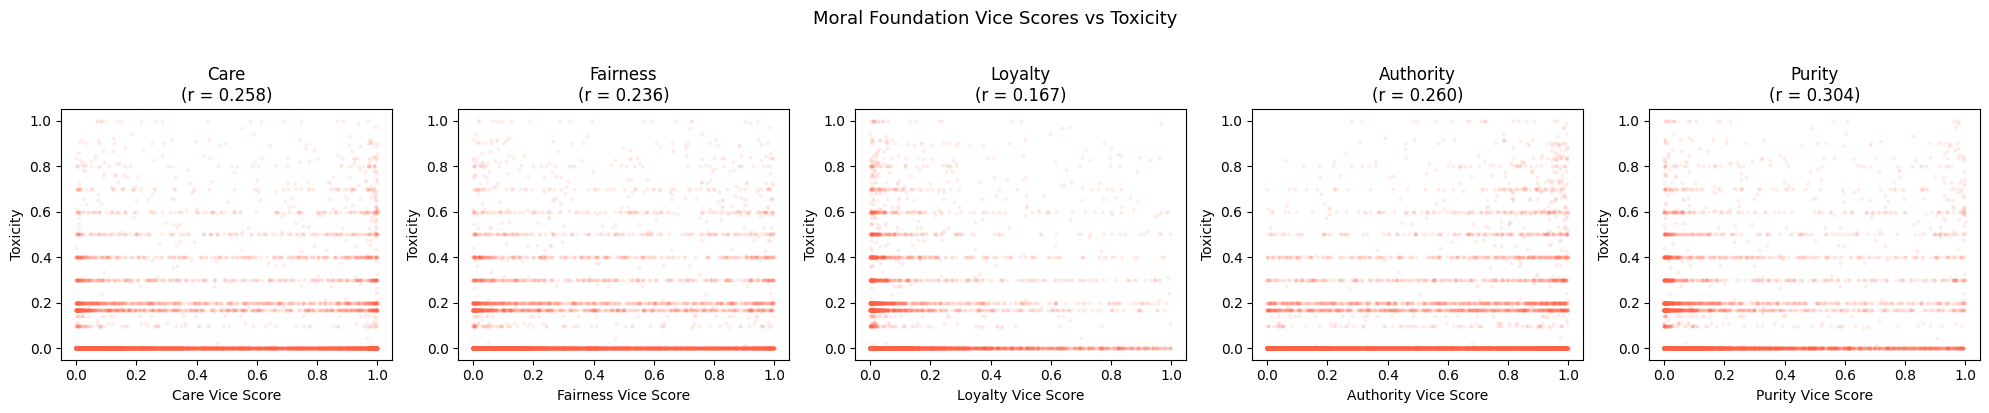

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
foundations = list(MF_LABELS.keys())

for ax, foundation in zip(axes, foundations):
    vice_col = f"mf_{foundation}_vice"
    ax.scatter(
        df_enriched[vice_col],
        df_enriched['toxicity'],
        alpha=0.08, s=4, color='tomato'
    )
    corr = df_enriched[vice_col].corr(df_enriched['toxicity'])
    ax.set_xlabel(f'{foundation.capitalize()} Vice Score')
    ax.set_ylabel('Toxicity')
    ax.set_title(f'{foundation.capitalize()}\n(r = {corr:.3f})')

plt.suptitle('Moral Foundation Vice Scores vs Toxicity', y=1.02, fontsize=13)
plt.tight_layout()

save_path = os.path.join(FIGURES_DIR, '02_mf_vs_toxicity_scatter.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved: {save_path}")
plt.show()

Saved: /content/drive/MyDrive/Civil Comments Project/outputs/figures/02_mf_correlation_heatmap.png


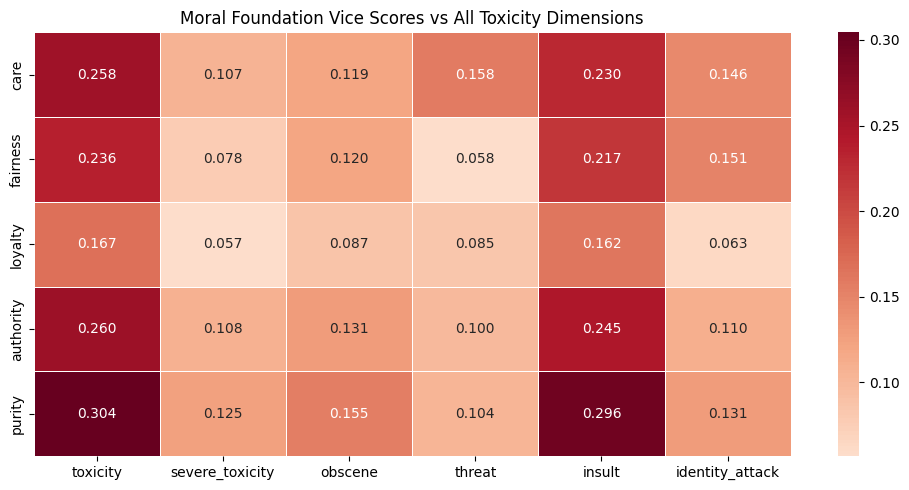

In [13]:
all_mf_cols = [f"mf_{f}_vice" for f in MF_LABELS.keys()]
score_cols  = ['toxicity', 'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack']

corr_matrix = df_enriched[all_mf_cols + score_cols].corr().loc[all_mf_cols, score_cols]
corr_matrix.index = [i.replace('mf_', '').replace('_vice', '') for i in corr_matrix.index]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Moral Foundation Vice Scores vs All Toxicity Dimensions', fontsize=12)
plt.tight_layout()

save_path = os.path.join(FIGURES_DIR, '02_mf_correlation_heatmap.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved: {save_path}")
plt.show()